In [ ]:
# Step 1: Load the phishing email dataset

import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/rokibulroni/Phishing-Email-Dataset/main/PhishingEmailData.csv"

# Try Latin-1 encoding
df = pd.read_csv(url, encoding="latin-1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (189, 13)

First 5 rows:


,Email_Subject,Email_Content,Sending_Date,Sending_Time,Day,URL_Title,Coined.Word,Sender_Name,Sender_Title,Closing_Remarks,Sender_Email,Logo,To
0,URGENT REQUEST,Are you available ?\nNo calls text only 951307...,1/9/20,na,na,na,Urgent,Y,Chancellor\nBerkeley University of California,BEST REGARDS,cchristberkeley.edu@gmail.com,na,NB
1,Quick question,I'm in a meeting and need help getting some Am...,1/9/20,na,na,na,Quick,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NB
2,******Part time home work assistant needed******,Hello RECIPIENT\n\nI am urgently seeking for a...,10/19/19,2:22 PM,Sat,na,Job/Needed,Y,*Professor David Card*\n*Department of Economi...,Sincerely,dvdmson @ gmail . Com,na,NB
3,Ê vendor payment,Are you around? I need to pay a vendor with th...,12/27/18\n,na,na,na,"gift card, meeting",Y,"University of California, Berkeley",na,ÊÊXXX.subdomain.berkeley.edu@gmail.com,na,NB
4,Quick question,I'm in a meeting and need help getting some Am...,12/27/18\n,na,na,na,shared,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NaN



Column names:
['Email_Subject', 'Email_Content', 'Sending_Date', 'Sending_Time', 'Day', 'URL_Title', 'Coined.Word', 'Sender_Name', 'Sender_Title', 'Closing_Remarks', 'Sender_Email ', 'Logo', 'To']


In [ ]:
print(df.columns.tolist())
print(df.shape)
display(df.head())

['Email_Subject', 'Email_Content', 'Sending_Date', 'Sending_Time', 'Day', 'URL_Title', 'Coined.Word', 'Sender_Name', 'Sender_Title', 'Closing_Remarks', 'Sender_Email ', 'Logo', 'To']
(189, 13)


,Email_Subject,Email_Content,Sending_Date,Sending_Time,Day,URL_Title,Coined.Word,Sender_Name,Sender_Title,Closing_Remarks,Sender_Email,Logo,To
0,URGENT REQUEST,Are you available ?\nNo calls text only 951307...,1/9/20,na,na,na,Urgent,Y,Chancellor\nBerkeley University of California,BEST REGARDS,cchristberkeley.edu@gmail.com,na,NB
1,Quick question,I'm in a meeting and need help getting some Am...,1/9/20,na,na,na,Quick,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NB
2,******Part time home work assistant needed******,Hello RECIPIENT\n\nI am urgently seeking for a...,10/19/19,2:22 PM,Sat,na,Job/Needed,Y,*Professor David Card*\n*Department of Economi...,Sincerely,dvdmson @ gmail . Com,na,NB
3,Ê vendor payment,Are you around? I need to pay a vendor with th...,12/27/18\n,na,na,na,"gift card, meeting",Y,"University of California, Berkeley",na,ÊÊXXX.subdomain.berkeley.edu@gmail.com,na,NB
4,Quick question,I'm in a meeting and need help getting some Am...,12/27/18\n,na,na,na,shared,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NaN


In [ ]:
# Step 2: Inspect columns and identify the target label

print("Dataset shape:", df.shape)

print("\nColumn names:")
for col in df.columns:
    print(repr(col))

print("\nFirst 5 rows:")
display(df.head())

print("\nUnique values in each column:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))

Dataset shape: (189, 13)

Column names:
'Email_Subject'
'Email_Content'
'Sending_Date'
'Sending_Time'
'Day'
'URL_Title'
'Coined.Word'
'Sender_Name'
'Sender_Title'
'Closing_Remarks'
'Sender_Email '
'Logo'
'To'

First 5 rows:


,Email_Subject,Email_Content,Sending_Date,Sending_Time,Day,URL_Title,Coined.Word,Sender_Name,Sender_Title,Closing_Remarks,Sender_Email,Logo,To
0,URGENT REQUEST,Are you available ?\nNo calls text only 951307...,1/9/20,na,na,na,Urgent,Y,Chancellor\nBerkeley University of California,BEST REGARDS,cchristberkeley.edu@gmail.com,na,NB
1,Quick question,I'm in a meeting and need help getting some Am...,1/9/20,na,na,na,Quick,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NB
2,******Part time home work assistant needed******,Hello RECIPIENT\n\nI am urgently seeking for a...,10/19/19,2:22 PM,Sat,na,Job/Needed,Y,*Professor David Card*\n*Department of Economi...,Sincerely,dvdmson @ gmail . Com,na,NB
3,Ê vendor payment,Are you around? I need to pay a vendor with th...,12/27/18\n,na,na,na,"gift card, meeting",Y,"University of California, Berkeley",na,ÊÊXXX.subdomain.berkeley.edu@gmail.com,na,NB
4,Quick question,I'm in a meeting and need help getting some Am...,12/27/18\n,na,na,na,shared,Y,"University of California, Berkeley",na,XXX.subdomain.berkeley.edu,na,NaN



Unique values in each column:

Email_Subject:
Email_Subject
Messages containing Locky malware                     2
Lesson Coach Needed                                   2
message notification                                  2
Your incoming email delivery reports                  2
Quick question                                        1
ÊXXX has shared a document on Google Docs with you    1
Message from human resources                          1
Ê vendor payment                                      1
******Part time home work assistant needed******      1
Your Dropbox File                                     1
Name: count, dtype: int64

Email_Content:
Email_Content
call missed                                                      3
I'm in a meeting and need help getting some Amazon Gift Cards    2
audio                                                            2
shared docx                                                      2
file                                                   

In [ ]:
# Step 3: Combine email subject and content

# Replace missing values with empty strings
df["Email_Subject"] = df["Email_Subject"].fillna("")
df["Email_Content"] = df["Email_Content"].fillna("")

# Combine subject + email content
df["Text"] = (
    df["Email_Subject"].astype(str) + " " +
    df["Email_Content"].astype(str)
)

# Remove rows where there is no useful text
df = df[df["Text"].str.strip() != ""].copy()

print("Number of emails:", len(df))

print("\nExample email:")
print(df["Text"].iloc[0])

Number of emails: 189

Example email:
URGENT REQUEST Are you available ?
No calls text only 9513072XXX


In [ ]:
# Step 4: Look for possible classification/label columns

print("All columns:")
print(df.columns.tolist())

print("\nColumns with relatively few unique values:")

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count <= 10:
        print("\nColumn:", col)
        print("Unique values:", df[col].unique())
        print("Counts:")
        print(df[col].value_counts(dropna=False))

All columns:
['Email_Subject', 'Email_Content', 'Sending_Date', 'Sending_Time', 'Day', 'URL_Title', 'Coined.Word', 'Sender_Name', 'Sender_Title', 'Closing_Remarks', 'Sender_Email ', 'Logo', 'To', 'Text']

Columns with relatively few unique values:

Column: Sender_Name
Unique values: ['Y' 'na' 'Na' 'y' nan]
Counts:
Sender_Name
Y      151
na      34
y        2
Na       1
NaN      1
Name: count, dtype: int64

Column: To
Unique values: ['NB' nan 'BCC' 'B' 'BN' ' B']
Counts:
To
B      161
NB      23
NaN      2
BCC      1
BN       1
 B       1
Name: count, dtype: int64


In [ ]:
# Step 5: Inspect the dataset for hidden/encoded labels

print("Dataset shape:", df.shape)

# Show the last few rows
display(df.tail())

# Check the index
print("\nIndex:")
print(df.index)

# Check data types
print("\nData types:")
print(df.dtypes)

# Check all unique values for the metadata columns
for col in ["Sender_Name", "To", "Logo", "URL_Title", "Coined.Word"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Dataset shape: (189, 14)


,Email_Subject,Email_Content,Sending_Date,Sending_Time,Day,URL_Title,Coined.Word,Sender_Name,Sender_Title,Closing_Remarks,Sender_Email,Logo,To,Text
184,Sales Contract PO:#224906999,2 new message,"February 12th, 2019",9.32am,tue,review,"sales, review",Y,Y,thanks,Y,na,B,Sales Contract PO:#224906999 2 new message
185,new bill from Ian,your bill is here,"February 12th, 2019",2.15pm,tue,invoice connect,"bill,",Y,Y,thank you,Y,na,B,new bill from Ian your bill is here
186,Re: Payment Invoice,please check your,"February 12th, 2019",2.17am EST,na,na,"invoice, payment",Y,Y,Thank you,Y,na,B,Re: Payment Invoice please check your
187,KSU Infringement,"email has been reposted , regulation","February 9th, 2019",11.21am EST,na,URL Redacted,"reported, regulations, policies",Y,Y,Sincerely,Y,na,B,"KSU Infringement email has been reposted , reg..."
188,We recieved your request,request to deactivate,"January 29th, 2019",2.11pm,tue,cancel,"request, cancel, deactivate,",Y,Y,na,Y,offcie 365,B,We recieved your request request to deactivate



Index:
RangeIndex(start=0, stop=189, step=1)

Data types:
Email_Subject      object
Email_Content      object
Sending_Date       object
Sending_Time       object
Day                object
URL_Title          object
Coined.Word        object
Sender_Name        object
Sender_Title       object
Closing_Remarks    object
Sender_Email       object
Logo               object
To                 object
Text               object
dtype: object

--- Sender_Name ---
Sender_Name
Y      151
na      34
y        2
Na       1
NaN      1
Name: count, dtype: int64

--- To ---
To
B      161
NB      23
NaN      2
BCC      1
BN       1
 B       1
Name: count, dtype: int64

--- Logo ---
Logo
na                       131
Microsoft                 15
offcie 365                 5
Office 365                 4
microsoft                  3
NaN                        2
Google Drive               2
Office365                  2
office 365                 2
PayPal                     2
Pay.service secure         1
Depa

In [ ]:
# Step 5: Load a labeled phishing-email dataset

!pip -q install datasets

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("fadzero02/phishing-email-dataset")

# Convert the training split to pandas
phishing_df = dataset["train"].to_pandas()

print("Dataset loaded successfully!")
print("Shape:", phishing_df.shape)

print("\nColumns:")
print(phishing_df.columns.tolist())

print("\nFirst 5 rows:")
display(phishing_df.head())

README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv: reconstructing file:   0%|          |  0.00B / 52.0MB            

Phishing_Email.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

Dataset loaded successfully!
Shape: (18650, 3)

Columns:
['Unnamed: 0', 'Email Text', 'Email Type']

First 5 rows:


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
print("Email Type values:")
print(phishing_df["Email Type"].value_counts())

print("\nMissing values:")
print(phishing_df[["Email Text", "Email Type"]].isnull().sum())

Email Type values:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Missing values:
Email Text    16
Email Type     0
dtype: int64


In [ ]:
# Step 7: Clean data and encode labels

import re

# Keep only the columns we need
data = phishing_df[["Email Text", "Email Type"]].copy()

# Remove emails with missing text
data = data.dropna(subset=["Email Text"])

# Convert email text to string
data["Email Text"] = data["Email Text"].astype(str)

# Clean the email text
def clean_text(text):
    text = text.lower()                         # lowercase
    text = re.sub(r"http\S+|www\S+", " URL ", text)  # replace URLs
    text = re.sub(r"\S+@\S+", " EMAIL ", text)      # replace email addresses
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)      # remove special characters
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text

data["Clean_Text"] = data["Email Text"].apply(clean_text)

# Convert labels:
# Safe Email = 0
# Phishing Email = 1

data["Label"] = data["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Remove any unexpected labels
data = data.dropna(subset=["Label"])

# Convert labels to integer
data["Label"] = data["Label"].astype(int)

print("Total emails:", len(data))

print("\nLabel distribution:")
print(data["Label"].value_counts())

print("\nSample cleaned email:")
print(data["Clean_Text"].iloc[0])

display(data.head())

Total emails: 18634

Label distribution:
Label
0    11322
1     7312
Name: count, dtype: int64

Sample cleaned email:
re 6 1100 disc uniformitarianism re 1086 sex lang dick hudson s observations on us use of s on but not d aughter as a vocative are very thought provoking but i am not sure that it is fair to attribute this to sons being treated like senior relatives for one thing we do n t normally use brother in this way any more than we do d aughter and it is hard to imagine a natural class comprising senior relatives and s on but excluding brother for another there seem to me to be differences here if i am not imagining a distinction that is not there it seems to me that the senior relative terms are used in a wider variety of contexts e g calling out from a distance to get someone s attention and hence at the beginning of an utterance whereas s on seems more natural in utterances like yes son hand me that son than in ones like son or son help me although perhaps these latter ones ar

,Email Text,Email Type,Clean_Text,Label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,re 6 1100 disc uniformitarianism re 1086 sex l...,0
1,the other side of * galicismos * * galicismo *...,Safe Email,the other side of galicismos galicismo is a sp...,0
2,re : equistar deal tickets are you still avail...,Safe Email,re equistar deal tickets are you still availab...,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,software at incredibly low prices 86 lower dra...,1


In [ ]:
# Step 8: Split into training and testing data

from sklearn.model_selection import train_test_split

X = data["Clean_Text"]
y = data["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 14907
Testing samples: 3727

Training label distribution:
Label
0    9057
1    5850
Name: count, dtype: int64

Testing label distribution:
Label
0    2265
1    1462
Name: count, dtype: int64


In [ ]:
# Step 9: Tokenization and Padding

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Maximum number of words in our vocabulary
vocab_size = 15000

# Maximum length of each email sequence
max_length = 200

# Create tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Learn vocabulary ONLY from training data
tokenizer.fit_on_texts(X_train)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Vocabulary size:", len(tokenizer.word_index))
print("Training data shape:", X_train_pad.shape)
print("Testing data shape:", X_test_pad.shape)

print("\nExample original text:")
print(X_train.iloc[0][:300])

print("\nExample tokenized sequence:")
print(X_train_seq[0][:30])

print("\nExample padded sequence:")
print(X_train_pad[0][:30])

Vocabulary size: 140271
Training data shape: (14907, 200)
Testing data shape: (3727, 200)

Example original text:
journal of japanese linguistics vol 15 content length 3687 i am sending the following announcement of the new issue vol 15 of the journal of japanese linguistics on behalf of the editors all inquiries should be addressed to the journal s addresses surface e mail fax provided below the announcement i

Example tokenized sequence:
[645, 3, 682, 84, 1300, 129, 592, 924, 1, 11, 116, 917, 2, 164, 1028, 3, 2, 59, 460, 1300, 129, 3, 2, 645, 3, 682, 84, 12, 1945, 3]

Example padded sequence:
[ 645    3  682   84 1300  129  592  924    1   11  116  917    2  164
 1028    3    2   59  460 1300  129    3    2  645    3  682   84   12
 1945    3]


In [ ]:
# Step 10: Build the RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 11: Compile the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Step 12: Train the RNN model

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.6034 - loss: 0.6660 - val_accuracy: 0.6147 - val_loss: 0.6227
Epoch 2/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.7229 - loss: 0.5376 - val_accuracy: 0.7391 - val_loss: 0.5452
Epoch 3/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.7019 - loss: 0.5564 - val_accuracy: 0.6144 - val_loss: 0.6447
Epoch 4/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.7033 - loss: 0.4999 - val_accuracy: 0.5654 - val_loss: 0.6768
Epoch 5/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.7047 - loss: 0.4784 - val_accuracy: 0.5962 - val_loss: 0.7405


In [ ]:
# Step 13: Evaluate the RNN model

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6075 - loss: 0.7264

Test Loss: 0.7264
Test Accuracy: 0.6075
Test Accuracy (%): 60.75 %


In [ ]:
# Step 14: Generate predictions

y_probability = model.predict(X_test_pad)

# Convert probability to class
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
Predictions generated successfully!

First 10 actual labels:
[0 0 0 1 0 0 1 0 1 1]

First 10 predicted labels:
[0 1 0 1 0 0 0 1 0 0]


Confusion Matrix:
[[2024  241]
 [1222  240]]


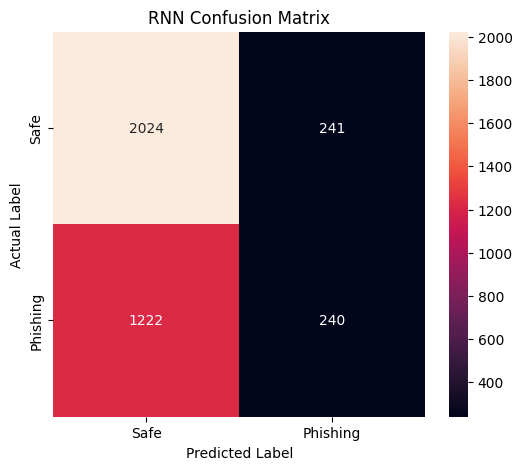

In [ ]:
# Step 15: Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Safe", "Phishing"],
    yticklabels=["Safe", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("RNN Confusion Matrix")
plt.show()

In [ ]:
# Step 16: Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Safe Email", "Phishing Email"]
    )
)

                precision    recall  f1-score   support

    Safe Email       0.62      0.89      0.73      2265
Phishing Email       0.50      0.16      0.25      1462

      accuracy                           0.61      3727
     macro avg       0.56      0.53      0.49      3727
  weighted avg       0.57      0.61      0.54      3727



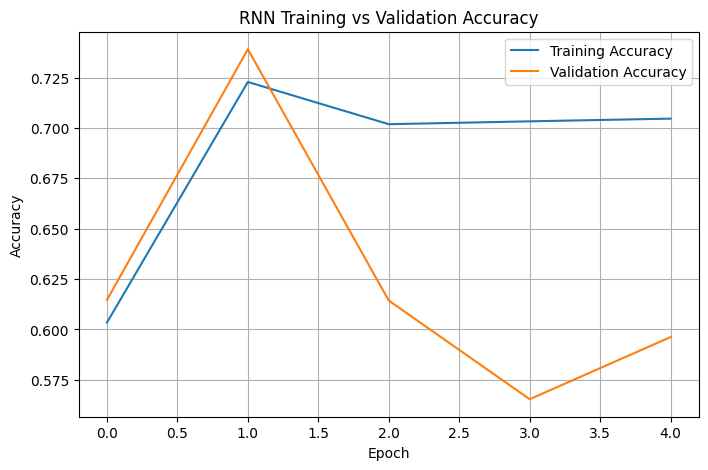

In [ ]:
# Step 17: Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

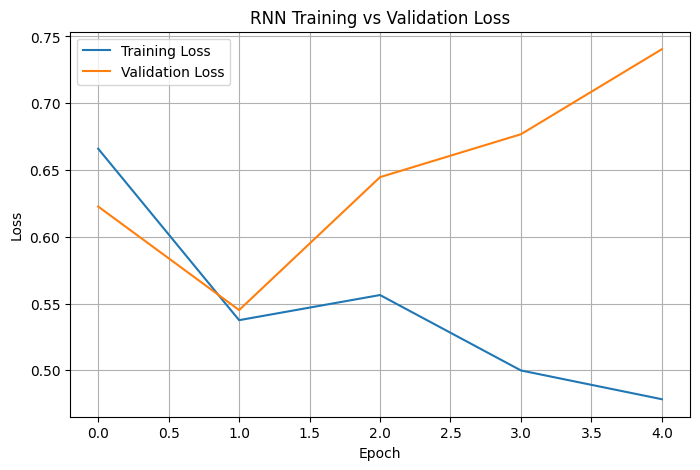

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 18: Predict a new email

def predict_email(email_text):
    cleaned = clean_text(email_text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "PHISHING EMAIL"
        confidence = probability
    else:
        prediction = "SAFE EMAIL"
        confidence = 1 - probability

    print("\nEmail:")
    print(email_text)

    print("\nPrediction:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")


# Test example
predict_email(
    "Urgent! Your bank account has been suspended. "
    "Click this link immediately to verify your account."
)


Email:
Urgent! Your bank account has been suspended. Click this link immediately to verify your account.

Prediction: SAFE EMAIL
Confidence: 56.03 %


In [ ]:
predict_email(
    "Hi, please find the meeting schedule attached. "
    "We will meet tomorrow at 10 AM."
)


Email:
Hi, please find the meeting schedule attached. We will meet tomorrow at 10 AM.

Prediction: SAFE EMAIL
Confidence: 56.03 %


In [ ]:
# Save the trained RNN model
model.save("phishing_rnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("phishing_rnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [ ]:
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
vocab_size = 15000
max_length = 200

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)